In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

prices = pd.read_csv("../prices.txt", sep=r"\s+")
assets = list(prices.columns)
prices.head()

returns = prices.pct_change()

market_returns = returns.sum(axis=1)

market_lookback_z = market_returns.rolling(window=2).mean()/market_returns.rolling(window=20).std()




z_algo = (returns["ALGO"] - returns["ALGO"].mean())/(returns["ALGO"].std())
market_returns.head()




0    0.000000
1   -0.771775
2   -0.341434
3    0.102619
4    0.582126
dtype: float64

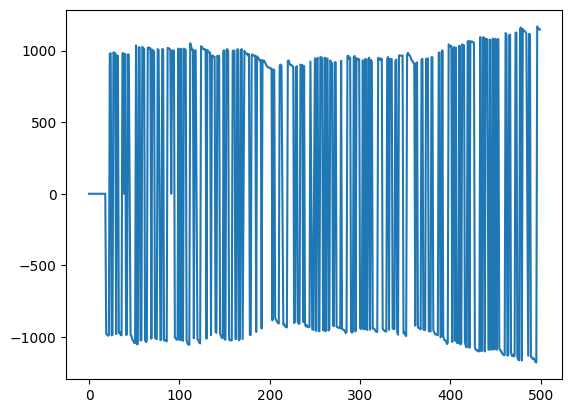

In [40]:
thresh = abs(market_lookback_z.sum()/len(market_lookback_z))

algo_pos = 0
POSITION_LIMIT = 100000
algo_prices = prices["ALGO"]
positions = []

for i in range(len(market_lookback_z)):
    z = market_lookback_z.iloc[i]
    algo_price = algo_prices.iloc[i]
    if z is not None and abs(z) >= thresh:
        target_dollars = np.sign(z)*POSITION_LIMIT
    else:
        target_dollars = 0
    target_shares = int(target_dollars/algo_price)
    max_shares = int(POSITION_LIMIT / algo_price)
    new_pos = int(np.clip(target_shares, -max_shares, max_shares))
    positions.append(new_pos)

positions = pd.Series(positions, index=algo_prices.index)


In [51]:
def calc_score(daily_pnl):
    mean_pl = daily_pnl.mean()
    std_pl = daily_pnl.std()

    if std_pl == 0:
        sharpe = 0
    else:
        sharpe = np.sqrt(250) * mean_pl / std_pl

    if mean_pl <= 0 or std_pl < 1e-10:
        score = mean_pl
    else:
        score = mean_pl * sharpe**2 / (sharpe**2 + 1)

    return score, sharpe, mean_pl, std_pl

best_score = -np.inf
best_thresh = None
best_direction = None

POSITION_LIMIT = 100_000
COMM_RATE = 0.00002
algo_prices = prices["ALGO"]

thresholds = np.arange(0.1, 2.5, 0.001)

for thresh in thresholds:
    for direction_type in ["momentum", "reversal"]:

        positions = []

        for t in range(len(market_lookback_z)):
            z = market_lookback_z.iloc[t]
            price = algo_prices.iloc[t]

            if pd.notna(z) and abs(z) >= thresh:
                if direction_type == "momentum":
                    target_dollars = np.sign(z) * POSITION_LIMIT
                else:
                    target_dollars = -np.sign(z) * POSITION_LIMIT
            else:
                target_dollars = 0

            target_shares = int(target_dollars / price)
            max_shares = int(POSITION_LIMIT / price)
            new_pos = int(np.clip(target_shares, -max_shares, max_shares))

            positions.append(new_pos)

        positions = pd.Series(positions, index=algo_prices.index)

        daily_pnl = []
        cash = 0
        cur_pos = 0
        value = 0
        comm = 0

        for t in range(1, len(algo_prices)):
            price = algo_prices.iloc[t - 1]

            new_pos = positions.iloc[t - 1]
            delta_pos = new_pos - cur_pos

            cash -= price * delta_pos + comm

            traded_dollars = price * abs(delta_pos)
            comm = traded_dollars * COMM_RATE

            cur_pos = new_pos
            new_value = cash + cur_pos * price

            today_pnl = new_value - value
            value = new_value

            daily_pnl.append(today_pnl)

        daily_pnl = np.array(daily_pnl)

        score, sharpe, mean_pl, std_pl = calc_score(daily_pnl)

        if score > best_score:
            best_score = score
            best_thresh = thresh
            best_direction = direction_type
            best_sharpe = sharpe
            best_mean = mean_pl
            best_std = std_pl

print("best score:", best_score)
print("best threshold:", best_thresh)
print("best direction:", best_direction)
print("best sharpe:", best_sharpe)
print("mean:", best_mean)
print("std:", best_std)

best score: 61.08815426409509
best threshold: 0.1
best direction: reversal
best sharpe: 1.5083578609895907
mean: 87.93839731943919
std: 921.8158253633172
